# 02. Análisis Exploratorio de Datos: Heart Disease

**Base seleccionada por el equipo: Heart Disease.** Se utiliza el mismo CSV
enlazado en la fase 1 y en el EDA actualizado del equipo. Se conservan las
secciones 2.1–2.4 de ese trabajo y se añaden relaciones multivariadas, hipótesis,
visualizaciones e insights en las secciones 2.5–2.8.

**Objetivo:** describir las asociaciones entre las variables y las clases de
`target`, así como los problemas de calidad que deben considerarse en la fase 3.
La copia contiene 303 registros y 14 columnas, incluida la variable objetivo.

**Alcance de las etiquetas:** este CSV es una versión recodificada. La
[documentación original de UCI](https://archive.ics.uci.edu/dataset/45/heart+disease)
describe un objetivo `num` con valores 0–4 y categorías distintas de las observadas
aquí. El [repositorio de la copia](https://github.com/sharmaroshan/Heart-UCI-Dataset)
reproduce esa descripción, pero no documenta claramente cómo se obtuvo el `target`
binario. Por ello se reportan **clase 0 y clase 1**, sin asumir cuál representa
presencia o ausencia de enfermedad. Resolver esa correspondencia es un pendiente
de documentación antes de interpretar clínicamente las clases.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from hashlib import sha256
from IPython.display import display, Markdown

In [2]:
# Misma fuente que en el notebook de exploración y en el EDA del equipo.
# Leer primero la copia local para poder repetir el análisis sin conexión.
raiz = Path.cwd() if (Path.cwd() / "02_eda").is_dir() else Path.cwd().parent
if not (raiz / "01_exploracion" / "exploracion_datasets.ipynb").exists():
    raise FileNotFoundError("Ejecuta desde la raíz del proyecto o desde 02_eda/.")
RUTA_CSV = raiz / "data" / "Heart_Disease_UCI.csv"
url_heart = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
origen = str(RUTA_CSV) if RUTA_CSV.exists() else url_heart
df_heart = pd.read_csv(origen)
print("Fuente:", origen)
print(df_heart.head())
print("Dimensiones:", df_heart.shape)
carpeta_figuras = raiz / "02_eda" / "figuras_heart"
carpeta_figuras.mkdir(exist_ok=True)

Fuente: /Applications/MAMP/htdocs/analisis-datos-evento2-grupo7/data/Heart_Disease_UCI.csv
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Dimensiones: (303, 14)


In [3]:
# Guardar solo cuando no hay una copia local; conservar el archivo original.
RUTA_CSV.parent.mkdir(parents=True, exist_ok=True)
if not RUTA_CSV.exists():
    df_heart.to_csv(RUTA_CSV, index=False)
print("SHA-256:", sha256(RUTA_CSV.read_bytes()).hexdigest())

SHA-256: 7c3014365675306819510a49ff289efbec1d1a6a666a2dc7652f1547b383d859


## 2.1 Revisión de valores faltantes:


In [4]:
# Verificación de los primeros registros del DataFrame.
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Verificación del tamaño del DataFrame.
df_heart.shape

(303, 14)

In [6]:
# verificación de registros, tipos de datos y valores nulos en el DataFrame.
df_heart.info() 

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# Revisión de valores faltantes
valores_faltantes = df_heart.isnull().sum()
porcentaje_faltantes = (valores_faltantes / len(df_heart)) * 100

resumen_faltantes = pd.DataFrame({
    "valores_faltantes": valores_faltantes,
    "porcentaje (%)": porcentaje_faltantes.round(2)
})
resumen_faltantes = resumen_faltantes[resumen_faltantes["valores_faltantes"] > 0]

if resumen_faltantes.empty:
    print("No se encontraron valores faltantes en ninguna columna.")
else:
    print("Columnas con valores faltantes:")
    print(resumen_faltantes.sort_values("porcentaje (%)", ascending=False))

No se encontraron valores faltantes en ninguna columna.


## 2.2 Detección de valores atípicos:

In [8]:
# Detección de valores atípicos.
# Estadisticas descriptivas de variables numericas.
numeric_cols = df_heart.select_dtypes(include="number").columns.tolist()
print(f"Variables numericas disponibles: {numeric_cols}")
print(len(numeric_cols))
df_heart[numeric_cols].describe().round(2)

Variables numericas disponibles: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [9]:
# Implementación de la detección de outliers utilizando el método IQR (Interquartile Range).
resumen_outliers_iqr = []
for col in numeric_cols:
    q1 = df_heart[col].quantile(0.25)
    q3 = df_heart[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df_heart[(df_heart[col] < limite_inferior) | (df_heart[col] > limite_superior)]
    resumen_outliers_iqr.append({
        "columna": col,
        "outliers_iqr": len(outliers),
        "porcentaje (%)": round(100 * len(outliers) / len(df_heart), 2)
    })
    
resumen_outliers_iqr = pd.DataFrame(resumen_outliers_iqr).sort_values(
    "outliers_iqr", ascending=False
)
print("Outliers detectados por IQR:")
print(resumen_outliers_iqr[resumen_outliers_iqr["outliers_iqr"] > 0])

Outliers detectados por IQR:
     columna  outliers_iqr  porcentaje (%)
5        fbs            45           14.85
11        ca            25            8.25
3   trestbps             9            2.97
4       chol             5            1.65
9    oldpeak             5            1.65
12      thal             2            0.66
7    thalach             1            0.33


In [10]:
# Variables cuantitativas continuas para evaluar posibles outliers
columnas_continuas = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Límites IQR y puntuaciones Z
resumen_outliers = []

for col in columnas_continuas:
    serie = df_heart[col]
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    z_score = (serie - serie.mean()) / serie.std()

    es_outlier_iqr = (serie < limite_inferior) | (serie > limite_superior)
    es_outlier_z = z_score.abs() > 3

    resumen_outliers.append({
        "columna": col,
        "outliers_IQR": int(es_outlier_iqr.sum()),
        "outliers_Z_score": int(es_outlier_z.sum())
    })

print("Resumen de posibles outliers:")
display(pd.DataFrame(resumen_outliers))

Resumen de posibles outliers:


,columna,outliers_IQR,outliers_Z_score
0,age,0,0
1,trestbps,9,2
2,chol,5,4
3,thalach,1,1
4,oldpeak,5,2


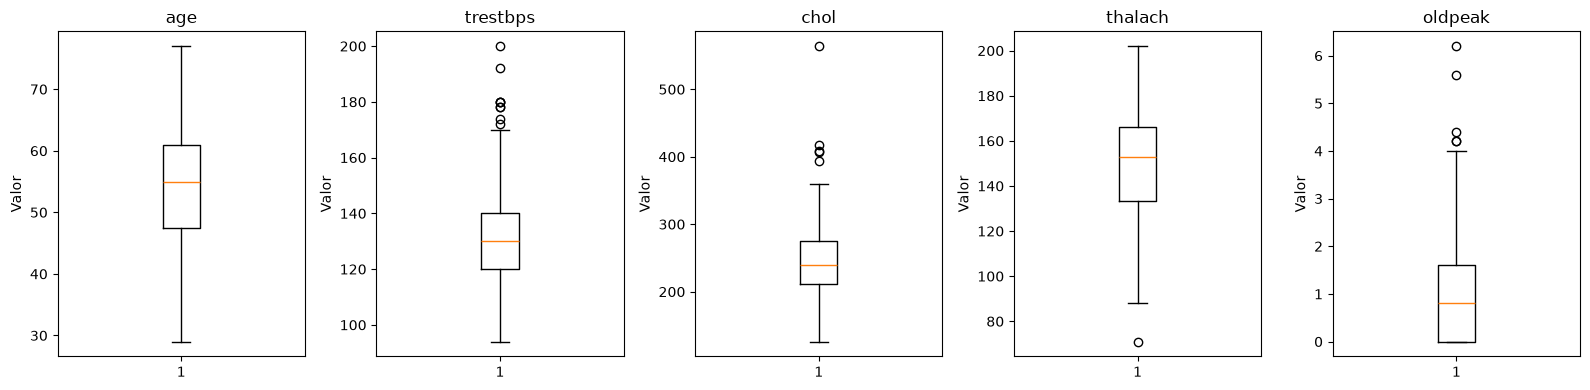

In [11]:
# Boxplots de las variables continuas.
fig, axes = plt.subplots(1, len(columnas_continuas), figsize=(16, 4))
for ax, col in zip(axes, columnas_continuas):
    ax.boxplot(df_heart[col].dropna())
    ax.set_title(col)
    ax.set_ylabel("Valor")
plt.tight_layout()
plt.savefig(carpeta_figuras / "00_boxplots_continuas.png", dpi=150, bbox_inches="tight")
plt.show()

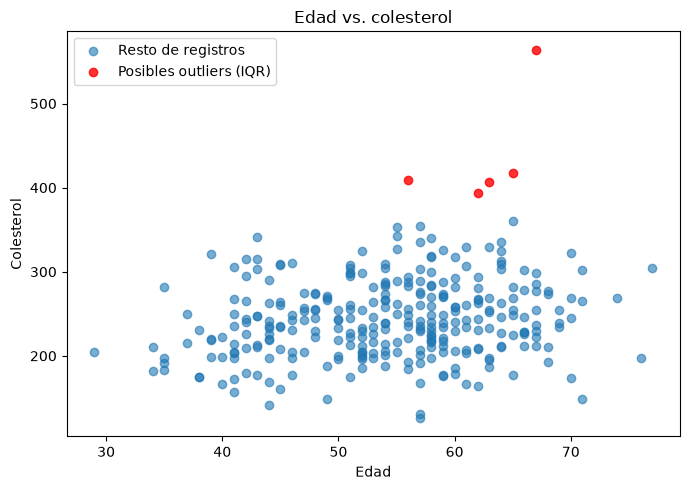

In [12]:
# Diagrama de dispersión: Edad vs. Colesterol.
# Se resaltan registros que son atípicos por IQR en cualquiera de las dos variables.
x_col, y_col = "age", "chol"

def mascara_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

posibles_outliers = (
    mascara_outliers_iqr(df_heart[x_col]) |
    mascara_outliers_iqr(df_heart[y_col])
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df_heart.loc[~posibles_outliers, x_col],
    df_heart.loc[~posibles_outliers, y_col],
    alpha=0.6,
    label="Resto de registros"
)
ax.scatter(
    df_heart.loc[posibles_outliers, x_col],
    df_heart.loc[posibles_outliers, y_col],
    color="red",
    alpha=0.8,
    label="Posibles outliers (IQR)"
)
ax.set_xlabel("Edad")
ax.set_ylabel("Colesterol")
ax.set_title("Edad vs. colesterol")
ax.legend()
plt.tight_layout()
plt.savefig(carpeta_figuras / "00_edad_colesterol.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 Análisis de distribuciones y 2.4 Análisis univariado

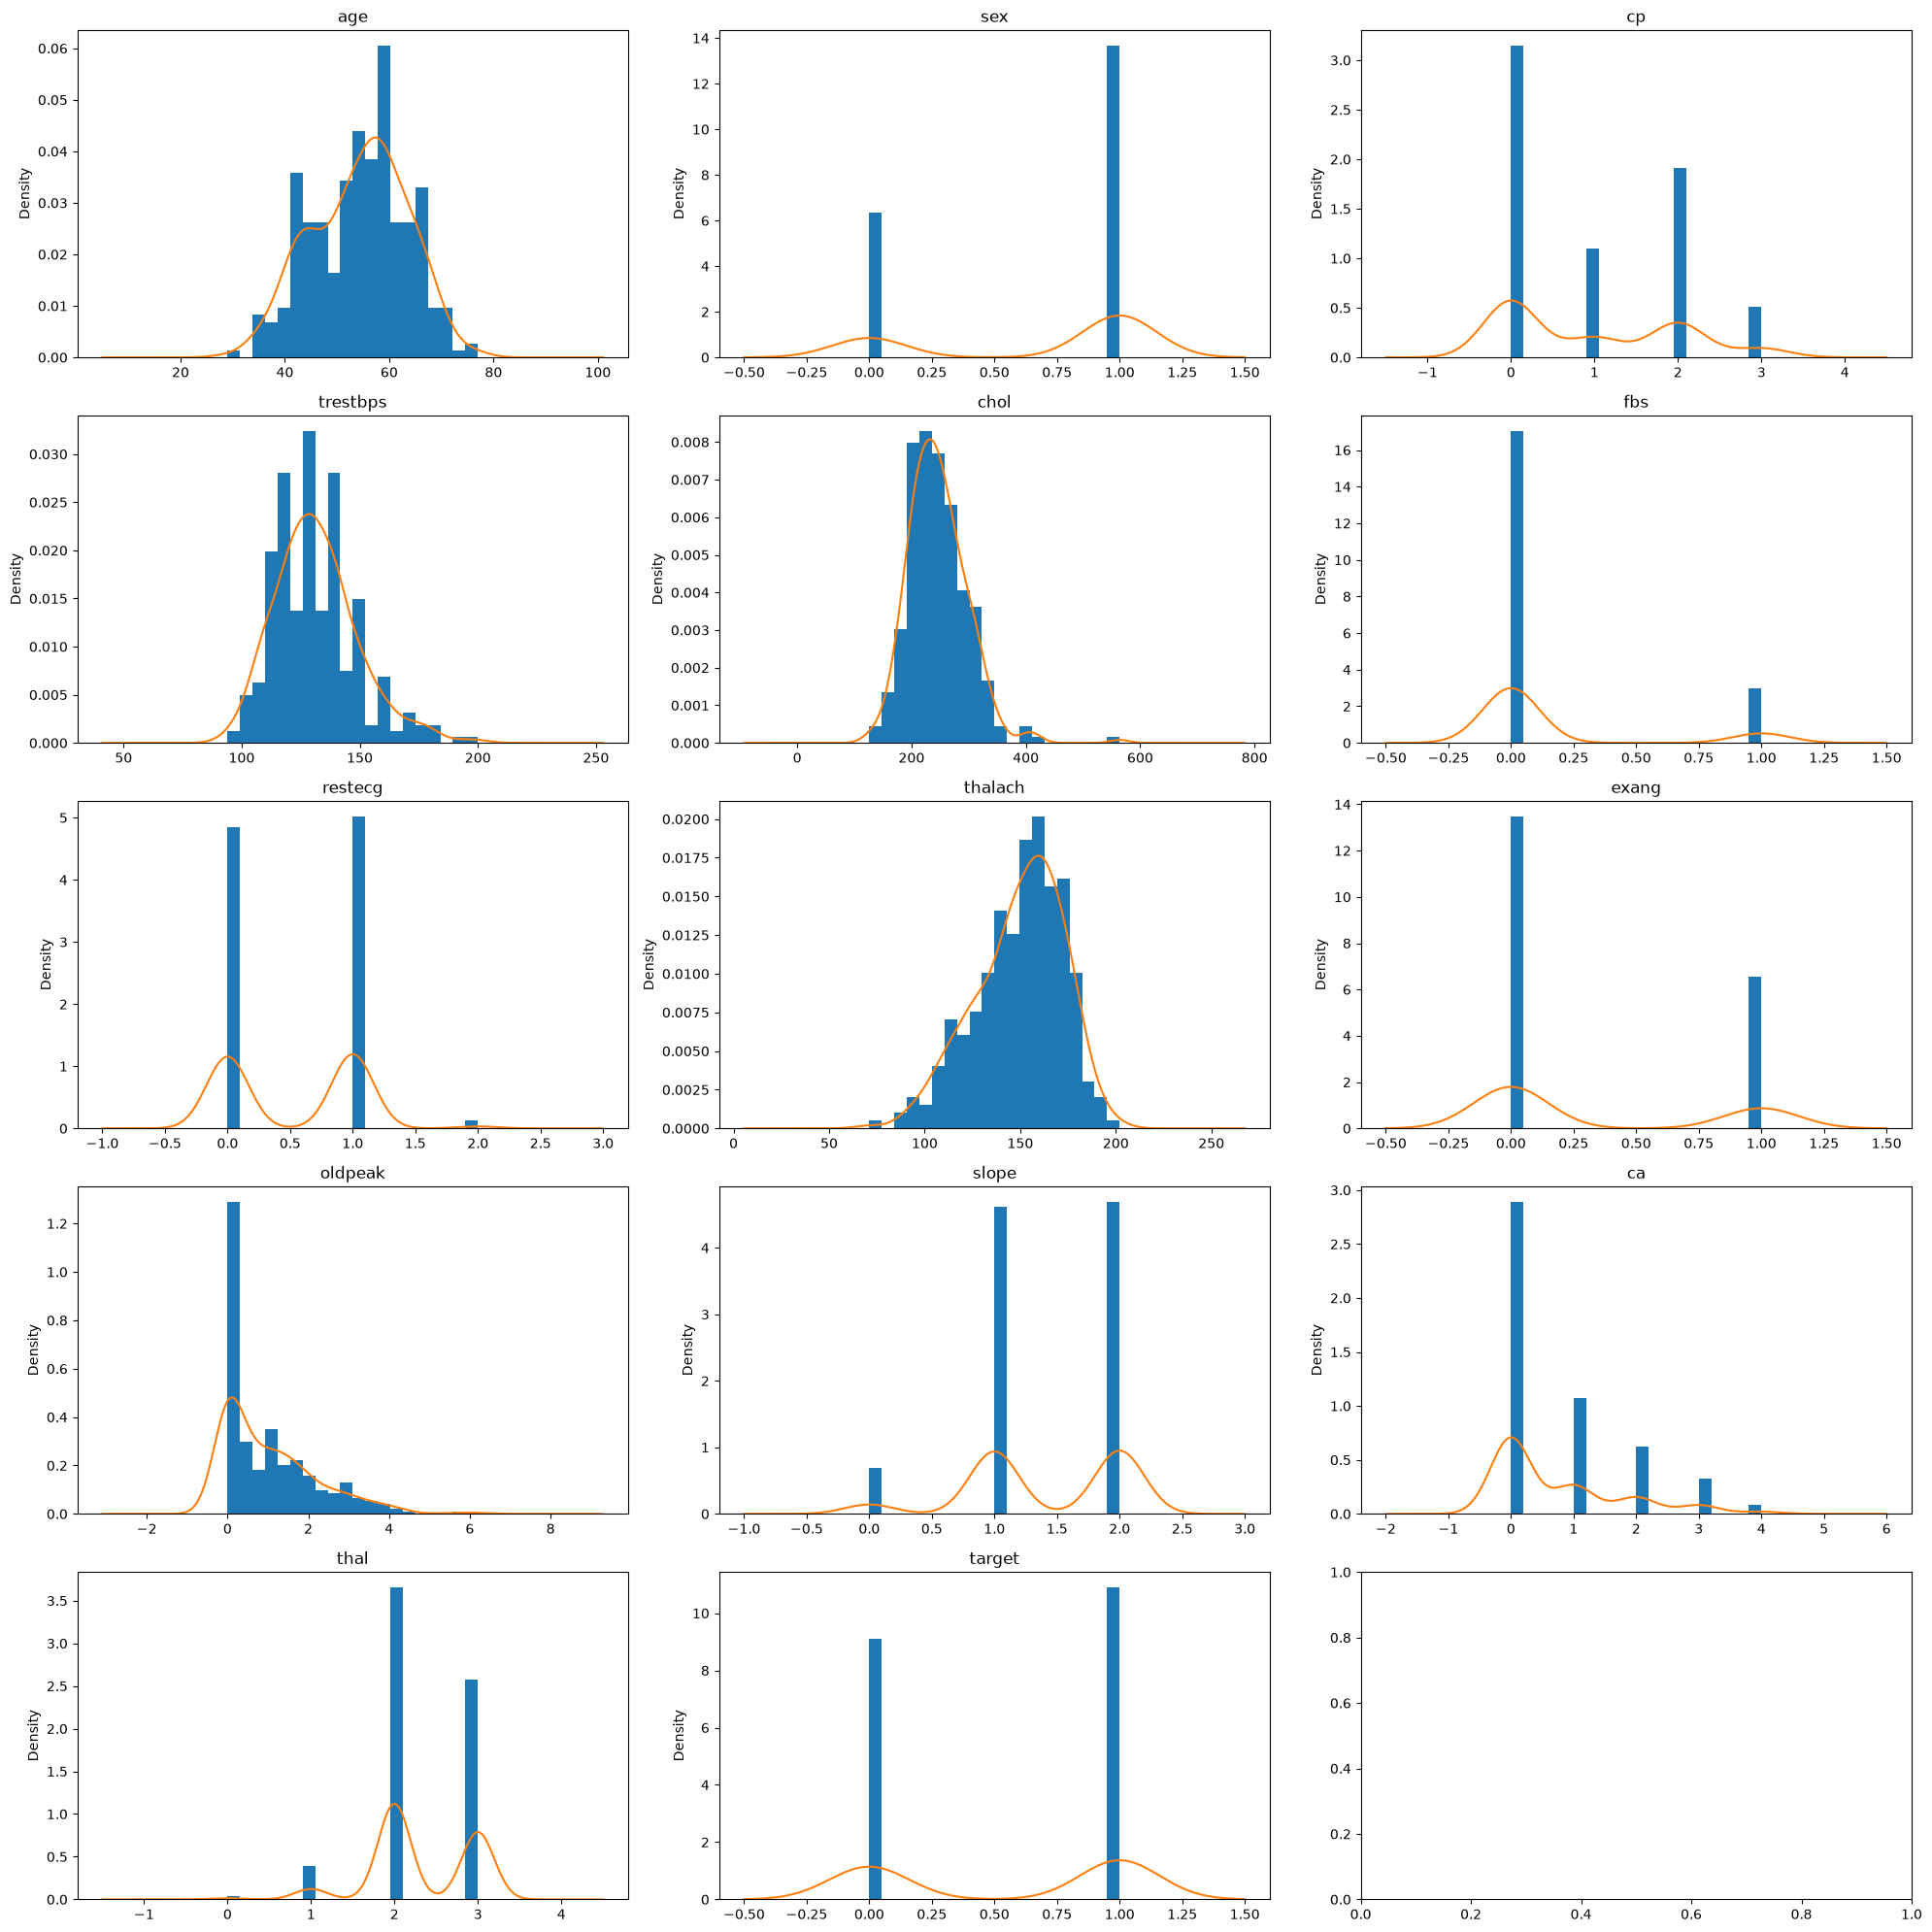

age        -0.202463
sex        -0.791335
cp          0.484732
trestbps    0.713768
chol        1.143401
fbs         1.986652
restecg     0.162522
thalach    -0.537410
exang       0.742532
oldpeak     1.269720
slope      -0.508316
ca          1.310422
thal       -0.476722
target     -0.179821
dtype: float64


In [13]:
# Análisis de distribuciones: histograma + densidad
columnas_numericas = df_heart.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 20))
axes = axes.flatten()

for ax, col in zip(axes, columnas_numericas):
    df_heart[col].plot(kind="hist", bins=20, density=True, ax=ax, title=col)
    if df_heart[col].std() > 0:
        df_heart[col].plot(kind="kde", ax=ax)

plt.tight_layout()
plt.savefig(carpeta_figuras / "00_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

# Sesgo de cada variable (se identifica posibles transformaciones necesarias)
print(df_heart[columnas_numericas].skew())

## 2.5 Análisis multivariado y relaciones entre variables

Aunque todas las columnas se almacenan como números, no todas son medidas
cuantitativas. Se estudian `age`, `trestbps`, `chol`, `thalach` y `oldpeak` con
correlaciones y boxplots; los códigos `sex`, `cp`, `fbs`, `restecg`, `exang`,
`slope` y `thal` se comparan como categorías. `ca` es un conteo, pero se tabula
por valor debido a su rango reducido y a los códigos pendientes de revisión.

Descripciones generales tomadas de [UCI](https://archive.ics.uci.edu/dataset/45/heart+disease):

| Variable | Descripción |
|---|---|
| `age` | Edad en años |
| `trestbps` | Presión arterial en reposo, en mm Hg |
| `chol` | Colesterol sérico, en mg/dl |
| `thalach` | Frecuencia cardiaca máxima alcanzada |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio respecto al reposo |

**Lectura del análisis previo:** aplicar IQR a un código binario como `fbs`
puede señalar su categoría menos frecuente sin que sea un error. La tabla de
IQR sobre todas las columnas se conserva como antecedente; el tratamiento de
atípicos debe apoyarse en las variables continuas y en su contexto. Asimismo,
las densidades de códigos discretos no implican que estos sean continuos.

In [14]:
# Validar el esquema y trabajar sobre una copia, sin limpiar todavía el original.
continuas = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categoricas = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
assert set(df_heart.columns) == set(continuas + categoricas + ["target"])
assert set(df_heart["target"].unique()) == {0, 1}
eda = df_heart.copy()
resumen_clases = eda["target"].value_counts().sort_index().to_frame("Registros")
resumen_clases["Porcentaje"] = 100 * resumen_clases["Registros"] / len(eda)
display(resumen_clases.round(2))
porcentaje_general = 100 * eda["target"].mean()
revision_codigos = (eda["ca"] == 4) | (eda["thal"] == 0)
calidad = pd.Series({
    "Registros": len(eda), "Columnas": eda.shape[1],
    "Celdas nulas": int(eda.isna().sum().sum()),
    "Duplicados completos adicionales": int(eda.duplicated().sum()),
    "Registros únicos": len(eda.drop_duplicates()),
    "Registros con ca = 4": int((eda["ca"] == 4).sum()),
    "Registros con thal = 0": int((eda["thal"] == 0).sum()),
    "Registros con alguno de esos códigos": int(revision_codigos.sum()),
}, name="Cantidad")
display(calidad.to_frame())
print("Filas idénticas (incluida la primera aparición):")
display(eda.loc[eda.duplicated(keep=False)])
print("Registros cuyos códigos requieren revisar la recodificación:")
display(eda.loc[revision_codigos, ["age", "ca", "thal", "target"]])

etiquetas = {"age": "Edad", "trestbps": "Presión en reposo", "chol": "Colesterol",
             "thalach": "Frecuencia máxima", "oldpeak": "Depresión ST"}
colores = {0: "#2878a0", 1: "#d47735"}

def guardar_figura(fig, nombre):
    fig.savefig(carpeta_figuras / nombre, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

,Registros,Porcentaje
target,,
0,138,45.54
1,165,54.46


,Cantidad
Registros,303
Columnas,14
Celdas nulas,0
Duplicados completos adicionales,1
Registros únicos,302
Registros con ca = 4,5
Registros con thal = 0,2
Registros con alguno de esos códigos,7


Filas idénticas (incluida la primera aparición):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


Registros cuyos códigos requieren revisar la recodificación:


,age,ca,thal,target
48,53,0,0,1
92,52,4,2,1
158,58,4,3,1
163,38,4,2,1
164,38,4,2,1
251,43,4,3,0
281,52,0,0,0


La revisión complementa los nulos: una fila repetida no prueba por sí sola que
se trate del mismo paciente, porque no hay identificador. En la documentación
original, `ca` se describe con valores 0–3, mientras que aquí aparece 4; `thal`
también usa códigos distintos y contiene ceros cuya interpretación no está
documentada en esta copia. Se conservan los 303 registros en el análisis principal.
No se recodifican esos valores como ausentes ni se eliminan automáticamente.

### 2.5.1 Correlaciones de variables cuantitativas

Pearson describe asociaciones lineales entre las cinco medidas continuas.
Spearman permite contrastar su dirección mediante rangos, considerando la
asimetría observada. Se excluyen los códigos categóricos del mapa de Pearson.
La correlación de cada medida con el `target` binario equivale a una correlación
puntual biserial; su signo se refiere exclusivamente a la codificación 0/1.

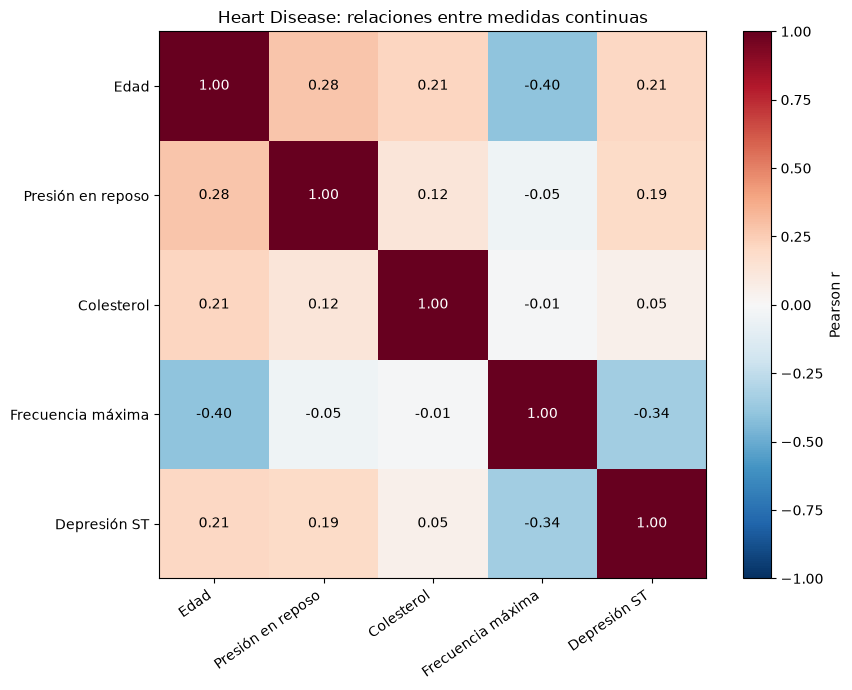

,Pearson con target,Spearman con target
age,-0.225,-0.238
trestbps,-0.145,-0.122
chol,-0.085,-0.121
thalach,0.422,0.428
oldpeak,-0.431,-0.421


**Lectura:** edad y frecuencia máxima presentan r = **-0.399**; frecuencia máxima y depresión ST, r = **-0.344**. Entre las medidas evaluadas, la frecuencia máxima y la depresión ST muestran las mayores asociaciones lineales en valor absoluto con target. El colesterol presenta una asociación lineal menor (r = **-0.085**), lo cual no descarta relaciones no lineales ni demuestra irrelevancia clínica.

In [15]:
correlacion = eda[continuas].corr(method="pearson")
fig, ax = plt.subplots(figsize=(9, 7))
mapa = ax.imshow(correlacion, cmap="RdBu_r", vmin=-1, vmax=1)
nombres = [etiquetas[c] for c in continuas]
ax.set_xticks(range(len(nombres)), nombres, rotation=35, ha="right")
ax.set_yticks(range(len(nombres)), nombres)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        r = correlacion.iloc[i, j]
        ax.text(j, i, f"{r:.2f}", ha="center", va="center",
                color="white" if abs(r) > 0.65 else "black")
ax.set_title("Heart Disease: relaciones entre medidas continuas")
fig.colorbar(mapa, ax=ax, label="Pearson r")
fig.tight_layout()
guardar_figura(fig, "01_correlaciones.png")

asociaciones = pd.DataFrame({
    "Pearson con target": eda[continuas + ["target"]].corr()["target"].drop("target"),
    "Spearman con target": eda[continuas + ["target"]].corr(method="spearman")["target"].drop("target"),
})
display(asociaciones.round(3))
display(Markdown(
    f"**Lectura:** edad y frecuencia máxima presentan r = "
    f"**{correlacion.loc['age', 'thalach']:.3f}**; frecuencia máxima y depresión ST, "
    f"r = **{correlacion.loc['thalach', 'oldpeak']:.3f}**. Entre las medidas evaluadas, "
    "la frecuencia máxima y la depresión ST muestran las mayores asociaciones "
    "lineales en valor absoluto con target. El colesterol presenta una asociación "
    f"lineal menor (r = **{asociaciones.loc['chol', 'Pearson con target']:.3f}**), "
    "lo cual no descarta relaciones no lineales ni demuestra irrelevancia clínica."
))

### 2.5.2 Tablas cruzadas y proporciones por categoría

Se calcula el porcentaje de `target = 1` **dentro de cada categoría**, junto
con los conteos de ambas clases y el tamaño del grupo. No debe confundirse con
prevalencia de enfermedad. Las barras incluyen intervalos de Wilson del 95 %
como referencia de incertidumbre bajo un supuesto binomial de observaciones
independientes; no garantizan representatividad ni son pruebas de hipótesis.
El posible duplicado también debe resolverse antes de inferencia formal.

Se mantienen los códigos originales de este CSV en las etiquetas. Los grupos
con menos de 30 registros se marcan con `*`; es un aviso descriptivo de tamaño
reducido, no un umbral de significancia estadística.


sex: clases y proporciones por categoría


target,Clase 0,Clase 1,Total,Clase 1 (%),IC95 inferior,IC95 superior
sex,,,,,,
0,24,72,96,75.00,65.49,82.59
1,114,93,207,44.93,38.31,51.73



cp: clases y proporciones por categoría


target,Clase 0,Clase 1,Total,Clase 1 (%),IC95 inferior,IC95 superior
cp,,,,,,
0,104,39,143,27.27,20.64,35.10
1,9,41,50,82.00,69.20,90.23
2,18,69,87,79.31,69.65,86.49
3,7,16,23,69.57,49.13,84.40



fbs: clases y proporciones por categoría


...

target,Clase 0,Clase 1,Total,Clase 1 (%),IC95 inferior,IC95 superior
slope,,,,,,
0,12,9,21,42.86,24.47,63.45
1,91,49,140,35.00,27.60,43.21
2,35,107,142,75.35,67.66,81.71



ca: clases y proporciones por categoría


target,Clase 0,Clase 1,Total,Clase 1 (%),IC95 inferior,IC95 superior
ca,,,,,,
0,45,130,175,74.29,67.34,80.19
1,44,21,65,32.31,22.20,44.39
2,31,7,38,18.42,9.22,33.42
3,17,3,20,15.00,5.24,36.04
4,1,4,5,80.00,37.55,96.38



thal: clases y proporciones por categoría


target,Clase 0,Clase 1,Total,Clase 1 (%),IC95 inferior,IC95 superior
thal,,,,,,
0,1,1,2,50.00,9.45,90.55
1,12,6,18,33.33,16.28,56.25
2,36,130,166,78.31,71.44,83.90
3,89,28,117,23.93,17.11,32.41


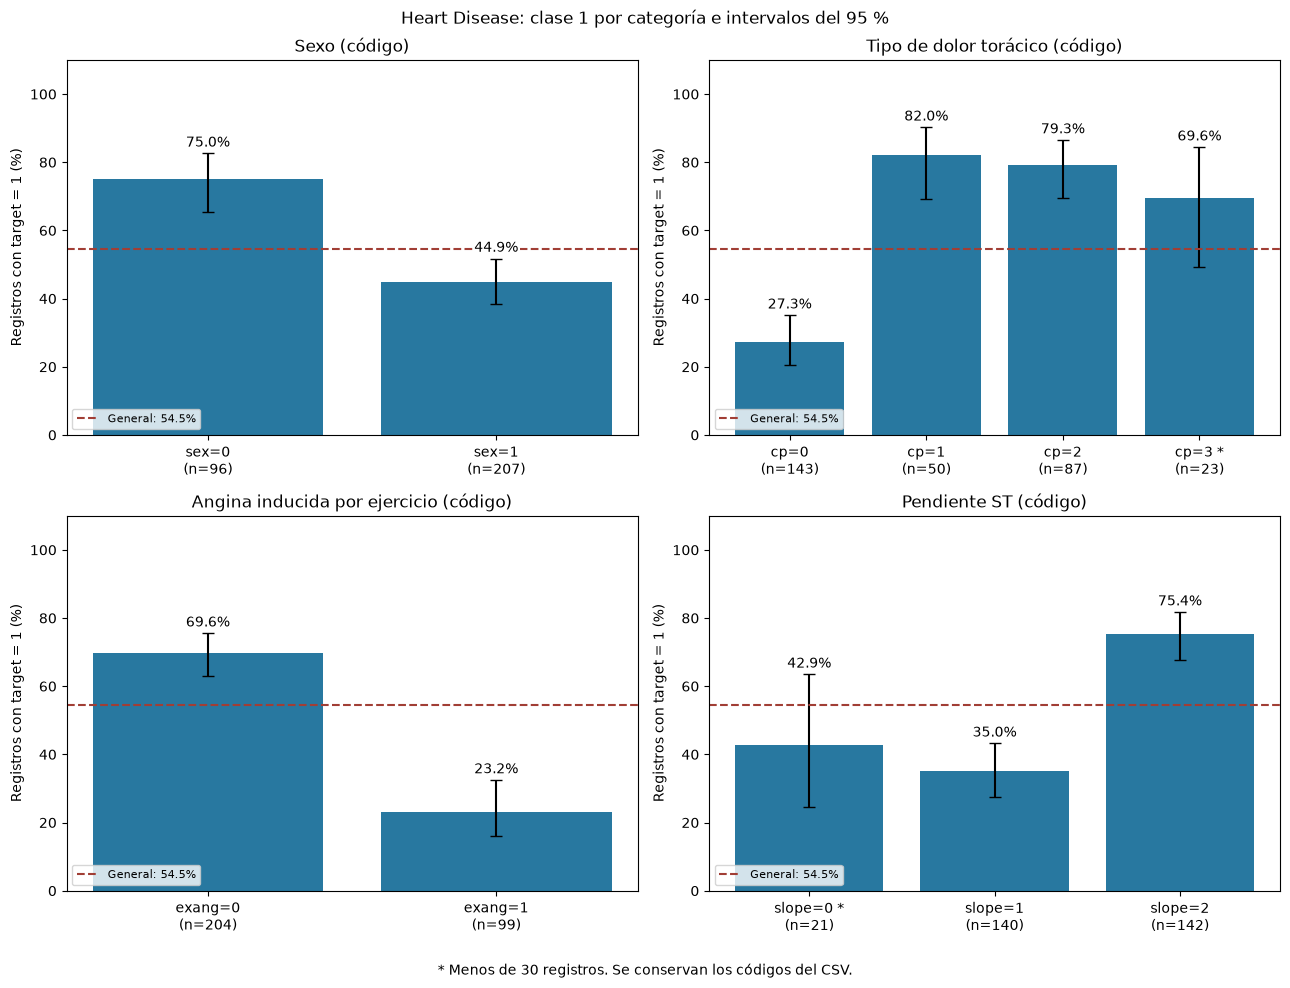

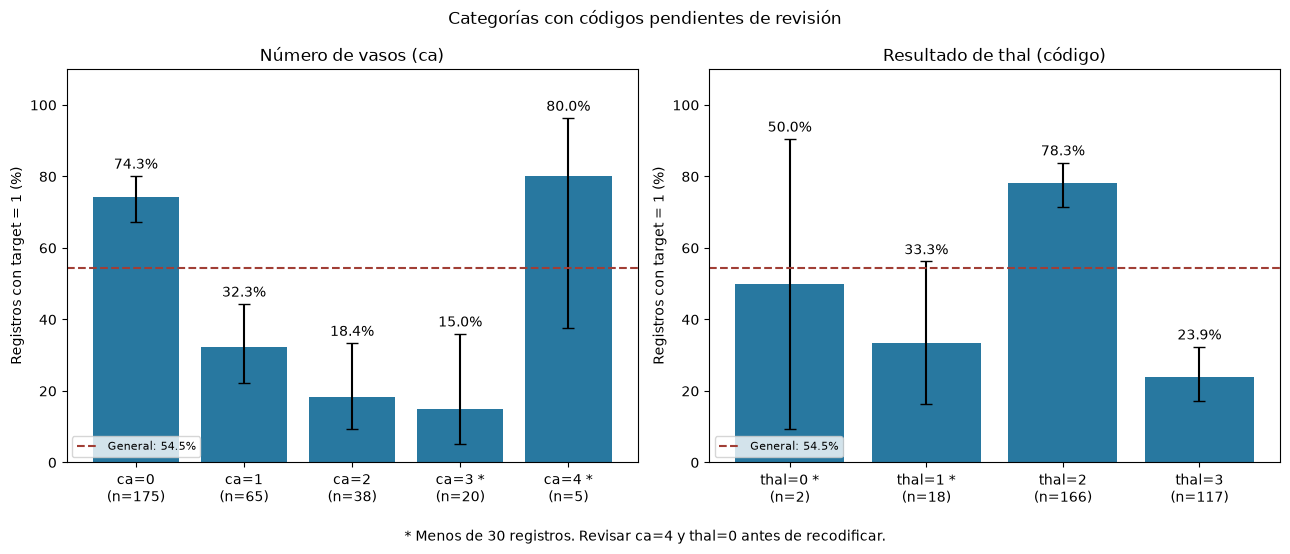

**Lectura:** el porcentaje de clase 1 es **69.61%** en exang=0 y **23.23%** en exang=1. En cp=0 es **27.27%**, frente a **82.00%** en cp=1. Son diferencias entre clases codificadas, no estimaciones de efecto causal. Las proporciones de ca=4 y thal=0 se basan en grupos muy pequeños y no admiten una interpretación estable.

In [16]:
def tabla_target(variable, datos=eda):
    tabla = pd.crosstab(datos[variable], datos["target"]).reindex(columns=[0, 1], fill_value=0)
    tabla = tabla.rename(columns={0: "Clase 0", 1: "Clase 1"})
    tabla["Total"] = tabla["Clase 0"] + tabla["Clase 1"]
    n = tabla["Total"]
    p = tabla["Clase 1"] / n
    z = 1.959963984540054
    centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    tabla["Clase 1 (%)"] = 100 * p
    tabla["IC95 inferior"] = 100 * (centro - margen)
    tabla["IC95 superior"] = 100 * (centro + margen)
    return tabla

tablas = {c: tabla_target(c) for c in categoricas}
for variable, tabla in tablas.items():
    print(f"\n{variable}: clases y proporciones por categoría")
    display(tabla.round(2))

def barras_categorias(ax, variable, titulo):
    tabla = tablas[variable]
    tasas = tabla["Clase 1 (%)"].to_numpy()
    errores = np.vstack([tasas - tabla["IC95 inferior"], tabla["IC95 superior"] - tasas])
    ax.bar(range(len(tabla)), tasas, color="#2878a0", yerr=errores, capsize=4)
    nombres = [f"{variable}={valor}{' *' if n < 30 else ''}\n(n={int(n)})"
               for valor, n in tabla["Total"].items()]
    ax.set_xticks(range(len(tabla)), nombres)
    for i, tasa in enumerate(tasas):
        ax.text(i, tabla["IC95 superior"].iloc[i] + 2, f"{tasa:.1f}%", ha="center",
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 1}, zorder=5)
    ax.axhline(porcentaje_general, color="#a13e35", linestyle="--",
               label=f"General: {porcentaje_general:.1f}%")
    ax.set_ylim(0, 110)
    ax.set_yticks(range(0, 101, 20))
    ax.set_ylabel("Registros con target = 1 (%)")
    ax.set_title(titulo)
    ax.legend(fontsize=8, loc="lower left")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col, titulo in zip(axes.flat, ["sex", "cp", "exang", "slope"],
                           ["Sexo (código)", "Tipo de dolor torácico (código)",
                            "Angina inducida por ejercicio (código)", "Pendiente ST (código)"]):
    barras_categorias(ax, col, titulo)
fig.suptitle("Heart Disease: clase 1 por categoría e intervalos del 95 %")
fig.text(0.5, 0.015, "* Menos de 30 registros. Se conservan los códigos del CSV.", ha="center")
fig.tight_layout(rect=[0, 0.04, 1, 1])
guardar_figura(fig, "02_target_por_categoria.png")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
barras_categorias(axes[0], "ca", "Número de vasos (ca)")
barras_categorias(axes[1], "thal", "Resultado de thal (código)")
fig.suptitle("Categorías con códigos pendientes de revisión")
fig.text(0.5, 0.015, "* Menos de 30 registros. Revisar ca=4 y thal=0 antes de recodificar.", ha="center")
fig.tight_layout(rect=[0, 0.05, 1, 1])
guardar_figura(fig, "03_target_ca_thal.png")

display(Markdown(
    f"**Lectura:** el porcentaje de clase 1 es **{tablas['exang'].loc[0, 'Clase 1 (%)']:.2f}%** "
    f"en exang=0 y **{tablas['exang'].loc[1, 'Clase 1 (%)']:.2f}%** en exang=1. "
    f"En cp=0 es **{tablas['cp'].loc[0, 'Clase 1 (%)']:.2f}%**, frente a "
    f"**{tablas['cp'].loc[1, 'Clase 1 (%)']:.2f}%** en cp=1. Son diferencias "
    "entre clases codificadas, no estimaciones de efecto causal. Las proporciones "
    "de ca=4 y thal=0 se basan en grupos muy pequeños y no admiten una interpretación estable."
))

### 2.5.3 Distribuciones conjuntas y perfiles por clase

Se comparan medianas y cuartiles de las cinco medidas. Los boxplots y la
dispersión de edad y frecuencia máxima, coloreada por `target`, permiten
comprobar diferencias y solapamiento entre clases.

age                    trestbps                        chol         \
       count median    Q1    Q3    count median     Q1      Q3 count median   
target                                                                        
0        138   58.0  52.0  62.0      138  130.0  120.0  144.75   138  249.0   
1        165   52.0  44.0  59.0      165  130.0  120.0  140.00   165  234.0   

                      thalach                      oldpeak                   
            Q1     Q3   count median     Q1     Q3   count median   Q1   Q3  
target                                                                       
0       217.25  283.0     138  142.0  125.0  156.0     138    1.4  0.6  2.5  
1       208.00  267.0     165  161.0  149.0  172.0     165    0.2  0.0  1.0

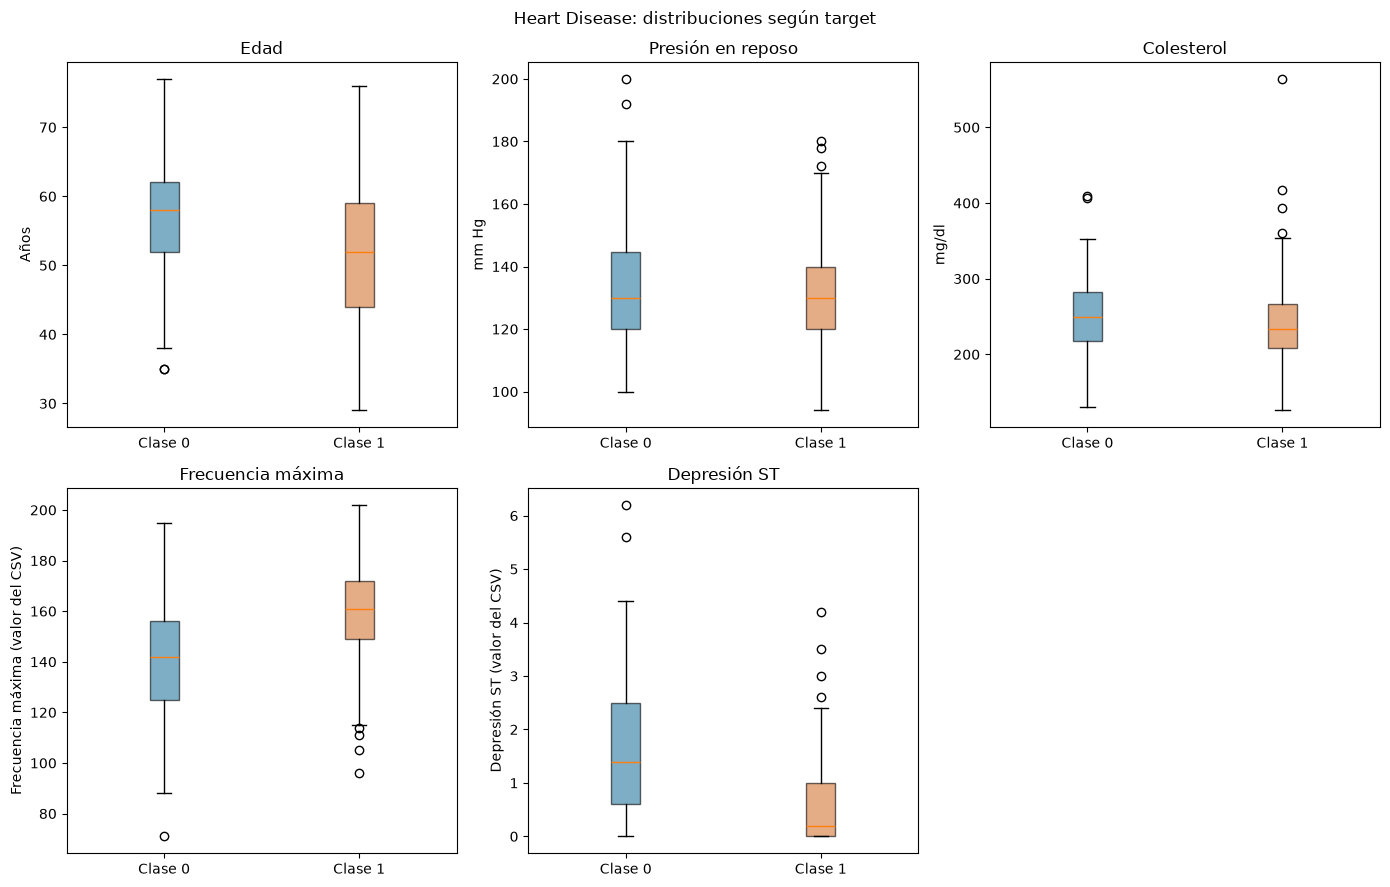

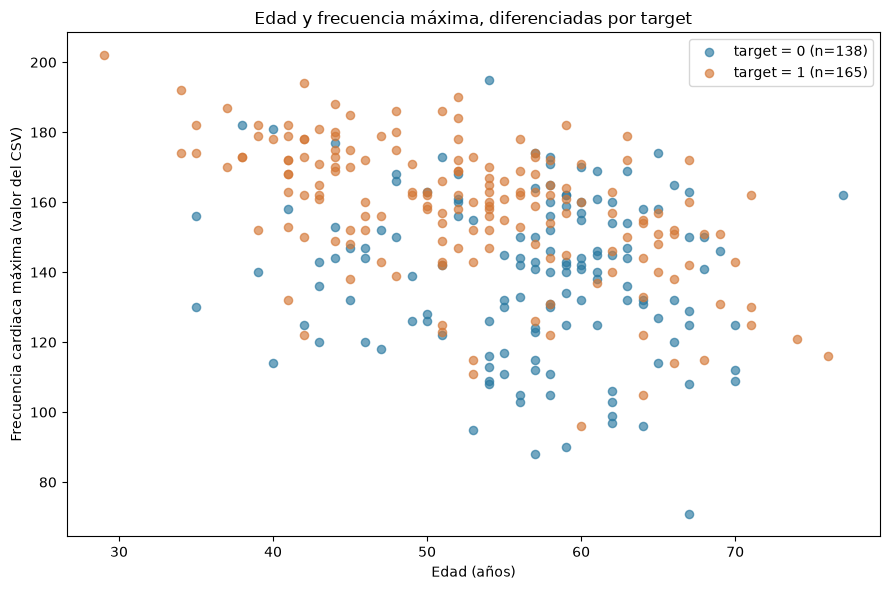

**Lectura:** la mediana de edad es **58** en clase 0 y **52** en clase 1. Las medianas de frecuencia máxima son **142** y **161**; las de oldpeak, **1.4** y **0.2**, respectivamente. Hay solapamiento entre grupos, por lo que esas medidas no separan perfectamente las clases ni constituyen reglas de diagnóstico.

In [17]:
resumen_perfiles = eda.groupby("target")[continuas].agg(
    ["count", "median", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)]
).rename(columns={"<lambda_0>": "Q1", "<lambda_1>": "Q3"})
display(resumen_perfiles.round(2))
medianas = eda.groupby("target")[continuas].median()
unidades = {"age": "Años", "trestbps": "mm Hg", "chol": "mg/dl",
            "thalach": "Frecuencia máxima (valor del CSV)", "oldpeak": "Depresión ST (valor del CSV)"}
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, col in zip(axes.flat, continuas):
    cajas = ax.boxplot([eda.loc[eda["target"] == clase, col] for clase in [0, 1]], patch_artist=True)
    for caja, clase in zip(cajas["boxes"], [0, 1]):
        caja.set_facecolor(colores[clase])
        caja.set_alpha(0.6)
    ax.set_xticks([1, 2], ["Clase 0", "Clase 1"])
    ax.set_title(etiquetas[col])
    ax.set_ylabel(unidades[col])
axes.flat[-1].set_visible(False)
fig.suptitle("Heart Disease: distribuciones según target")
fig.tight_layout()
guardar_figura(fig, "04_perfiles_por_target.png")

fig, ax = plt.subplots(figsize=(9, 6))
for clase in [0, 1]:
    grupo = eda.loc[eda["target"] == clase]
    ax.scatter(grupo["age"], grupo["thalach"], color=colores[clase], alpha=0.65,
               s=35, label=f"target = {clase} (n={len(grupo)})")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Frecuencia cardiaca máxima (valor del CSV)")
ax.set_title("Edad y frecuencia máxima, diferenciadas por target")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "05_edad_frecuencia_target.png")
display(Markdown(
    f"**Lectura:** la mediana de edad es **{medianas.loc[0, 'age']:.0f}** en clase 0 "
    f"y **{medianas.loc[1, 'age']:.0f}** en clase 1. Las medianas de frecuencia máxima "
    f"son **{medianas.loc[0, 'thalach']:.0f}** y **{medianas.loc[1, 'thalach']:.0f}**; "
    f"las de oldpeak, **{medianas.loc[0, 'oldpeak']:.1f}** y **{medianas.loc[1, 'oldpeak']:.1f}**, "
    "respectivamente. Hay solapamiento entre grupos, por lo que esas medidas no "
    "separan perfectamente las clases ni constituyen reglas de diagnóstico."
))

### 2.5.4 Análisis conjunto: sex, exang y target

Se compara la proporción de clase 1 según `exang` **dentro de cada categoría de
`sex`**. Esta estratificación incorpora tres variables y permite revisar si el
patrón global se mantiene al considerar una tercera. No controla simultáneamente
edad ni otros posibles factores de confusión.

Clase1  Total  Clase 1 (%)
sex exang                            
0   0          64     74        86.49
    1           8     22        36.36
1   0          78    130        60.00
    1          15     77        19.48

,exang=1 menos exang=0 (puntos porcentuales)
sex,
0,-50.12
1,-40.52


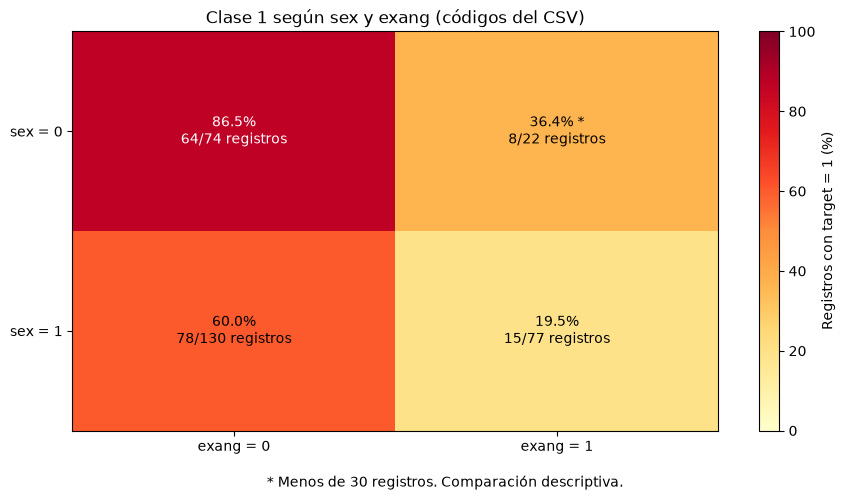

**Lectura:** la proporción de clase 1 es menor en exang=1 dentro de ambas categorías de sex. Las diferencias son **-50.12** y **-40.52 puntos porcentuales**, respectivamente. El grupo sex=0, exang=1 tiene pocos registros. El patrón no desaparece con esta estratificación, pero no identifica un efecto independiente ni causal.

In [18]:
estratos = eda.groupby(["sex", "exang"])["target"].agg(Clase1="sum", Total="count")
estratos["Clase 1 (%)"] = 100 * estratos["Clase1"] / estratos["Total"]
display(estratos.round(2))
tasas_estratos = estratos["Clase 1 (%)"].unstack("exang").reindex(columns=[0, 1])
diferencias = (tasas_estratos[1] - tasas_estratos[0]).rename("exang=1 menos exang=0 (puntos porcentuales)")
display(diferencias.round(2).to_frame())
fig, ax = plt.subplots(figsize=(9, 5))
mapa = ax.imshow(tasas_estratos, cmap="YlOrRd", vmin=0, vmax=100, aspect="auto")
ax.set_xticks([0, 1], ["exang = 0", "exang = 1"])
ax.set_yticks(range(len(tasas_estratos)), [f"sex = {s}" for s in tasas_estratos.index])
for i, sexo in enumerate(tasas_estratos.index):
    for j, angina in enumerate([0, 1]):
        fila = estratos.loc[(sexo, angina)]
        marca = " *" if fila["Total"] < 30 else ""
        ax.text(j, i, f"{fila['Clase 1 (%)']:.1f}%{marca}\n{int(fila['Clase1'])}/{int(fila['Total'])} registros",
                ha="center", va="center", color="white" if fila["Clase 1 (%)"] > 60 else "black")
ax.set_title("Clase 1 según sex y exang (códigos del CSV)")
fig.colorbar(mapa, ax=ax, label="Registros con target = 1 (%)")
fig.text(0.5, 0.015, "* Menos de 30 registros. Comparación descriptiva.", ha="center")
fig.tight_layout(rect=[0, 0.05, 1, 1])
guardar_figura(fig, "06_target_exang_por_sex.png")
display(Markdown(
    "**Lectura:** la proporción de clase 1 es menor en exang=1 dentro de ambas "
    f"categorías de sex. Las diferencias son **{diferencias.loc[0]:.2f}** y "
    f"**{diferencias.loc[1]:.2f} puntos porcentuales**, respectivamente. El grupo "
    "sex=0, exang=1 tiene pocos registros. El patrón no desaparece con esta "
    "estratificación, pero no identifica un efecto independiente ni causal."
))

### 2.5.5 Sensibilidad a los problemas de calidad

Se repiten dos resúmenes en copias temporales: sin filas repetidas y, además,
excluyendo provisionalmente los códigos `ca=4` o `thal=0`. La exclusión es un
escenario de sensibilidad, **no una decisión de limpieza** ni una afirmación
de que esos registros sean inválidos. El análisis principal conserva los datos.

In [19]:
sin_duplicados = eda.drop_duplicates()
escenarios = {
    "Original": eda,
    "Sin repetidos": sin_duplicados,
    "Sin repetidos ni códigos por revisar": sin_duplicados.loc[
        (sin_duplicados["ca"] != 4) & (sin_duplicados["thal"] != 0)
    ],
}
filas_sensibilidad = []
for nombre, datos in escenarios.items():
    tasas = tabla_target("exang", datos)["Clase 1 (%)"]
    filas_sensibilidad.append({
        "Escenario": nombre, "Registros": len(datos),
        "Clase 1 (%)": 100 * datos["target"].mean(),
        "Diferencia exang (1 menos 0), pp": tasas.loc[1] - tasas.loc[0],
        "Pearson thalach-target": datos[["thalach", "target"]].corr().iloc[0, 1],
    })
sensibilidad = pd.DataFrame(filas_sensibilidad).set_index("Escenario")
display(sensibilidad.round(3))
print("Se conserva el DataFrame original:", df_heart.shape, "y la copia principal:", eda.shape)

,Registros,Clase 1 (%),"Diferencia exang (1 menos 0), pp",Pearson thalach-target
Escenario,,,,
Original,303,54.455,-46.376,0.422
Sin repetidos,302,54.305,-46.226,0.420
Sin repetidos ni códigos por revisar,296,54.054,-45.133,0.427


Se conserva el DataFrame original: (303, 14) y la copia principal: (303, 14)


## 2.6 Construcción de hipótesis iniciales

Se proponen cinco hipótesis a partir de las asociaciones observadas. No se han
realizado pruebas de significancia ni se consideran confirmadas. Los contrastes
en esta misma muestra serían exploratorios: las hipótesis surgieron al observarla.
Antes de realizarlos, resolver la codificación de `target`, revisar duplicados,
frecuencias esperadas y ajustar por comparaciones múltiples si procede.

| Hipótesis | H0 (nula) | H1 (alternativa) | Evidencia del EDA y evaluación posterior |
|---|---|---|---|
| H1. Frecuencia máxima y target | La distribución de thalach es igual en ambas clases. | Las distribuciones difieren. | Medianas y boxplots; comparar rangos con Mann–Whitney y tamaño de efecto. No es exclusivamente una prueba de medianas salvo supuestos adicionales. |
| H2. Depresión ST y target | La distribución de oldpeak es igual en ambas clases. | Las distribuciones difieren. | Boxplots y correlaciones; comparación de rangos considerando asimetría y empates. |
| H3. exang y target | Las dos variables son independientes. | Existe asociación entre ellas. | Tablas generales y por sex; chi-cuadrado o Fisher según conteos y estimación de la diferencia de proporciones. |
| H4. Tipo de dolor torácico y target | cp y target son independientes. | Existe asociación entre ellos. | Tabla cruzada y barras; chi-cuadrado revisando frecuencias esperadas, con V de Cramér para magnitud. |
| H5. Edad y frecuencia máxima | No hay correlación lineal entre age y thalach. | Existe correlación lineal. | Mapa y dispersión; estimar correlación con intervalo y contrastar con Spearman. |

En una fase posterior se puede estudiar conjuntamente edad, sex, exang y otras
variables con un modelo adecuado, sin asumir independencia a partir de las
comparaciones bivariadas ni usar `target` para construir las variables predictoras.

## 2.7 Visualizaciones clave

Las figuras se muestran en las secciones anteriores y se exportan a `figuras_heart/`.

| Archivo | Hallazgo que ayuda a comunicar | Limitación |
|---|---|---|
| `01_correlaciones.png` | Relaciones entre edad, presión, colesterol, frecuencia máxima y depresión ST. | Pearson mide asociación lineal; no demuestra causalidad. |
| `02_target_por_categoria.png` | Proporciones de clase 1 por sex, cp, exang y slope. | Códigos del CSV; grupos desiguales e intervalos exploratorios. |
| `03_target_ca_thal.png` | Asociaciones de ca y thal y categorías escasas. | Revisar la documentación de ca=4 y thal=0. |
| `04_perfiles_por_target.png` | Diferencias y solapamiento de las cinco medidas entre clases. | Los perfiles no son reglas individuales. |
| `05_edad_frecuencia_target.png` | Relación entre edad y frecuencia máxima diferenciada por target. | Superposición de puntos y factores no considerados. |
| `06_target_exang_por_sex.png` | Asociación exang-target dentro de cada categoría de sex. | Estratificar por una variable no controla las demás. |

Para el video, priorizar las figuras 02, 06 y 04. Los archivos que comienzan por
`00_` corresponden a las visualizaciones del análisis previo del equipo.

## 2.8 Insights principales y líneas de continuación

Las cifras siguientes se calculan desde las tablas anteriores para mantener
los hallazgos sincronizados con los resultados del notebook.

In [20]:
insights = [
    f"**Distribución de clases:** {int(resumen_clases.loc[1, 'Registros'])} registros "
    f"son clase 1 ({porcentaje_general:.2f}%) y {int(resumen_clases.loc[0, 'Registros'])} "
    "son clase 0. Las clases tienen tamaños relativamente próximos; esto no permite estimar prevalencia clínica.",
    f"**Frecuencia máxima:** medianas de {medianas.loc[0, 'thalach']:.0f} en clase 0 "
    f"y {medianas.loc[1, 'thalach']:.0f} en clase 1; Pearson con target = "
    f"{asociaciones.loc['thalach', 'Pearson con target']:.3f}. Hay asociación y solapamiento entre grupos.",
    f"**Depresión ST:** medianas de {medianas.loc[0, 'oldpeak']:.1f} y "
    f"{medianas.loc[1, 'oldpeak']:.1f} para clases 0 y 1; Pearson con target = "
    f"{asociaciones.loc['oldpeak', 'Pearson con target']:.3f}. Conviene considerar la asimetría en la fase 3.",
    f"**exang y target:** clase 1 representa {tablas['exang'].loc[0, 'Clase 1 (%)']:.2f}% "
    f"en exang=0 y {tablas['exang'].loc[1, 'Clase 1 (%)']:.2f}% en exang=1. "
    "La diferencia conserva su dirección dentro de ambas categorías de sex, sin demostrar causalidad.",
    f"**Tipo de dolor torácico:** cp=0 tiene {tablas['cp'].loc[0, 'Clase 1 (%)']:.2f}% "
    f"de clase 1, frente a {tablas['cp'].loc[1, 'Clase 1 (%)']:.2f}% en cp=1. "
    "Se deben usar categorías, sin imponer una escala numérica o asumir la codificación original de UCI.",
    f"**Relaciones entre medidas:** edad y frecuencia máxima presentan Pearson "
    f"r = {correlacion.loc['age', 'thalach']:.3f}. El colesterol muestra una asociación "
    f"lineal débil con target (r = {asociaciones.loc['chol', 'Pearson con target']:.3f}); "
    "esto no justifica eliminarlo automáticamente ni una conclusión clínica.",
    f"**Calidad y codificación:** hay {int(eda.isna().sum().sum())} celdas nulas "
    f"y {int(eda.duplicated().sum())} fila repetida adicional. Se observan "
    f"{int((eda['ca'] == 4).sum())} registros con ca=4 y {int((eda['thal'] == 0).sum())} "
    "con thal=0. Revisar su procedencia y el significado de target antes de limpiar o interpretar clínicamente.",
    f"**Sensibilidad:** la diferencia exang=1 menos exang=0 pasa de "
    f"{sensibilidad.iloc[0]['Diferencia exang (1 menos 0), pp']:.2f} a "
    f"{sensibilidad.iloc[-1]['Diferencia exang (1 menos 0), pp']:.2f} puntos porcentuales "
    f"al comparar {int(sensibilidad.iloc[0]['Registros'])} con {int(sensibilidad.iloc[-1]['Registros'])} "
    "registros en el escenario más restrictivo. La dirección se mantiene; la exclusión sigue siendo provisional.",
]
display(Markdown("\n\n".join(f"{i}. {texto}" for i, texto in enumerate(insights, start=1))))

1. **Distribución de clases:** 165 registros son clase 1 (54.46%) y 138 son clase 0. Las clases tienen tamaños relativamente próximos; esto no permite estimar prevalencia clínica.

2. **Frecuencia máxima:** medianas de 142 en clase 0 y 161 en clase 1; Pearson con target = 0.422. Hay asociación y solapamiento entre grupos.

3. **Depresión ST:** medianas de 1.4 y 0.2 para clases 0 y 1; Pearson con target = -0.431. Conviene considerar la asimetría en la fase 3.

4. **exang y target:** clase 1 representa 69.61% en exang=0 y 23.23% en exang=1. La diferencia conserva su dirección dentro de ambas categorías de sex, sin demostrar causalidad.

5. **Tipo de dolor torácico:** cp=0 tiene 27.27% de clase 1, frente a 82.00% en cp=1. Se deben usar categorías, sin imponer una escala numérica o asumir la codificación original de UCI.

6. **Relaciones entre medidas:** edad y frecuencia máxima presentan Pearson r = -0.399. El colesterol muestra una asociación lineal débil con target (r = -0.085); esto no justifica eliminarlo automáticamente ni una conclusión clínica.

7. **Calidad y codificación:** hay 0 celdas nulas y 1 fila repetida adicional. Se observan 5 registros con ca=4 y 2 con thal=0. Revisar su procedencia y el significado de target antes de limpiar o interpretar clínicamente.

8. **Sensibilidad:** la diferencia exang=1 menos exang=0 pasa de -46.38 a -45.13 puntos porcentuales al comparar 303 con 296 registros en el escenario más restrictivo. La dirección se mantiene; la exclusión sigue siendo provisional.

**Conexión con la fase 3:** separar `target`; documentar los códigos; acordar el
tratamiento de repetidos y categorías por revisar; codificar las variables
categóricas sin tratarlas automáticamente como medidas continuas; escalar las
medidas y valorar transformaciones en las distribuciones asimétricas. Para PCA,
justificar las columnas incluidas y mantener `target` fuera de los componentes.
En un futuro modelo, evitar que registros repetidos queden en entrenamiento y
evaluación, y ajustar transformaciones únicamente sobre entrenamiento.

**Limitaciones:** muestra pequeña, categorías poco frecuentes, posible repetición
de registros y recodificación incompletamente documentada. El EDA muestra
asociaciones en esta copia; no identifica causas, no valida diagnósticos y no
generaliza automáticamente a otra población. Las hipótesis quedan propuestas
para una evaluación posterior.